# Coffee Quality Classification — Multiclass ML with scikit-learn Pipelines

**Course:** Diplomado en Machine Learning Aplicado (DMLA) · Pontificia Universidad Católica de Chile  
**Dataset:** [Coffee Quality Data (CQI May-2023)](https://www.kaggle.com/datasets/fatihb/coffee-quality-data-cqi) · 207 Arabica samples, 41 features  
**Author:** Ruth Sepúlveda Márquez  

---

**Problem:** Predict the quality class of a coffee sample (Average / Good / Excellent) from its sensory scores and physical attributes.  
**Key finding:** Random Forest achieves 0.95 accuracy and 0.91 balanced accuracy, substantially above the 0.33 dummy baseline. Overfitting analysis shows the Decision Tree memorises training data from depth 5 onward, while optimal generalisation occurs at `max_depth = 4`.

---

## Notebook structure

| Phase | Content |
|-------|---------|
| **Phase 1 — EDA** | Dataset overview · column audit · 5 charts (distribution, processing method, sensory scores × class, altitude, correlations) · null analysis |
| **Phase 2 — Feature engineering** | Column selection · data-leakage prevention · altitude classification · PCA + t-SNE visualisation |
| **Phase 3 — Modelling** | Stratified 80/20 split · scikit-learn Pipeline (ColumnTransformer) · Random Forest vs Decision Tree vs Dummy baseline · Confusion matrices · Overfitting curve |

## Dependencies

In [ ]:
# Instalación de dependencias
!pip install pandas numpy matplotlib seaborn scikit-learn -q
!pip install kagglehub

## Imports

In [ ]:
# Importar librerías
import pandas as pd
import kagglehub
import re
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import clone

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
import random
import numpy as np

# Para reproducibilidad
RNG_SEED = 0

random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

---
# 1. Data & Exploration

## 1.1 Dataset overview

### About the data

- **Nombre del dataset:** Coffee Quality Data (CQI May-2023)
- **Fuente:** https://www.kaggle.com/datasets/fatihb/coffee-quality-data-cqi
- **Descripción:** Recopilación de la Coffee Quality Institute (CQI) con evaluaciones sensoriales y físicas de 207 muestras de café Arábica evaluadas por Q-Graders certificados. Contiene puntajes sensoriales (Aroma, Flavor, Acidity, etc.), características físicas (humedad, altitud, defectos) y metadatos (país, variedad, método de procesamiento).
- **Tarea de predicción:** Clasificar la calidad del café en tres categorías (Average / Good / Excellent) derivadas del puntaje total de taza (Total Cup Points). Esto permite identificar qué atributos físicos y sensoriales distinguen un café de alta calidad.
- **Tipo de problema:** Clasificación

### Downloading the data

In [ ]:
# Kaggle credentials — load from environment variables (never hardcode keys)
# Set these in your terminal before running:
#   export KAGGLE_USERNAME='your-kaggle-username'
#   export KAGGLE_KEY='your-kaggle-api-key'
# Or create ~/.kaggle/kaggle.json — see https://www.kaggle.com/docs/api
import os
# os.environ['KAGGLE_USERNAME'] = 'YOUR_USERNAME'   # ← set in env, not here
# os.environ['KAGGLE_KEY']      = 'YOUR_API_KEY'    # ← set in env, not here

### Loading the data

In [ ]:
# Descargar el dataset desde Kaggle especificando su ruta
path = kagglehub.dataset_download('fatihb/coffee-quality-data-cqi')

print("Dataset descargado en la ruta:", path)

100%|██████████| 21.8k/21.8k [00:00<00:00, 20.0MB/s]

Extracting files...
Dataset descargado en la ruta: /root/.cache/kagglehub/datasets/fatihb/coffee-quality-data-cqi/versions/1


In [ ]:
import os
# Agregar la tabla y verificar las primeras columnas
coffee_file_path = os.path.join(path, 'df_arabica_clean.csv')
coffee = pd.read_csv(coffee_file_path)
coffee

,Unnamed: 0,ID,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
0,0,0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",...,89.33,11.8,0,0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,1,1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,...,87.58,10.5,0,0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,2,2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,...,87.42,10.4,0,0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
3,3,3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900,"Los Santos,Tarrazu",...,87.17,11.8,0,0,green,0,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
4,4,4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1850-2100,"Popayan,Cauca",...,87.08,11.6,0,2,yellow-green,2,"March 5th, 2024",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,202,202,Brazil,Fazenda Conquista,019/22,Dry Mill,NaN,Ipanema Coffees,950,Sul de Minas,...,80.08,11.4,0,0,green,4,"February 2nd, 2024",Brazil Specialty Coffee Association,"Rua Gaspar Batista Paiva, 416 – Santa Luiza Va...",Chris Allen - 55 35 3212-4705
203,203,203,Nicaragua,Finca San Felipe,017-053-0155,Beneficio Atlantic Sébaco,017-053-0155,Exportadora Atlantic S.A,1200,Matagalpa,...,80.00,10.4,0,2,green,12,"March 2nd, 2024",Asociación de Cafés Especiales de Nicaragua,"Del Hotel Seminole 2 C al lago, 1 C arriba.",Maria Ines Benavidez Toval - 011-(505)-8396 4717
204,204,204,Laos,-,105/3/VL7285-005,DRY MILL,105/3/VL7285-005,Marubeni Corporation,1300,Bolaven Plateau,...,79.67,11.6,0,9,green,11,"November 11th, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
205,205,205,El Salvador,"Rosario de Maria II, Area de La Pila",0423A01,"Optimum Coffee, San Salvador, El Salvador",NaN,Aprentium Enterprises LLC,1200,"Volcan de San Vicente, La Paz, El Salvador",...,78.08,11.0,0,12,bluish-green,13,"March 7th, 2024",Salvadoran Coffee Council,"Final 1a. Av. Norte y 13 Calle Pte., dentro de...",Tomas Bonilla - (503) 2505-6600


In [ ]:
coffee.shape

(207, 41)

El dataset es pequeño, sólo 207 filas, pero tiene 41 filas. Esto hace que, a pesar de su tamaño, tenga bastante información descriptiva interesante de utilizar. Dependiendo de las variables a dejar para el modelo, la idea será mantener la mayor cantidad de información y no eliminar outlier para no disminuir el dataset.

## 1.2 Column analysis

In [ ]:
info_columnas = [
    # (nombre_columna, tipo_estadístico, descripción_breve, rol)
    ('Unnamed: 0',            'Numérica continua',    'Orden de los datos',                                   'Identificador'),
    ('ID',                    'Numérica continua',    'Número de la muestra',                                 'Identificador'),
    ('Country of Origin',     'Categórica nominal',   'País donde se cultivó el café',                        'Predictora'),
    ('Farm Name',             'Categórica nominal',   'Nombre de la hacienda o finca',                        'Identificador'),
    ('Lot Number',            'Categórica nominal',   'Número de lote asignado al café',                      'Identificador'),
    ('Mill',                  'Categórica nominal',   'Nombre del molino donde se procesó',                   'Identificador'),
    ('ICO Number',            'Categórica nominal',   'Código de la Organización Internacional del Café',     'Identificador'),
    ('Company',               'Categórica nominal',   'Empresa exportadora o propietaria',                    'Identificador'),
    ('Altitude',              'Texto/mixto',          'Altitud en metros',                                    'Categoría para clasificar'),
    ('Region',                'Categórica nominal',   'Región geográfica de cultivo',                         'Predictora'),
    ('Producer',              'Categórica nominal',   'Nombre del productor',                                 'Identificador'),
    ('Number of Bags',        'Numérica entera',      'Número de sacos en el lote evaluado',                  'Predictora'),
    ('Bag Weight',            'Texto/mixto',          'Peso del saco',                                        'Texto mixto'),
    ('In-Country Partner',    'Categórica nominal',   'Organización socia en el país de origen',              'Identificador'),
    ('Harvest Year',          'Fecha / texto',        'Año de cosecha del café',                              'Fecha'),
    ('Grading Date',          'Fecha',                'Fecha en que se realizó la evaluación',                'Fecha'),
    ('Owner',                 'Categórica nominal',   'Dueños de la propiedad',                               'Identificador'),
    ('Variety',               'Categórica nominal',   'Variedad botánica del café',                           'Predictora'),
    ('Status',                'Categórica nominal',   'Estado del análisis',                                  'Identificador'),
    ('Processing Method',     'Categórica nominal',   'Método de procesamiento',                              'Predictora'),
    ('Aroma',                 'Numérica continua',    'Puntaje sensorial de aroma (escala 0–10)',             'Predictora'),
    ('Flavor',                'Numérica continua',    'Puntaje sensorial de sabor (escala 0–10)',             'Predictora'),
    ('Aftertaste',            'Numérica continua',    'Puntaje sensorial de retrogusto (escala 0–10)',        'Predictora'),
    ('Acidity',               'Numérica continua',    'Puntaje sensorial de acidez (escala 0–10)',            'Predictora'),
    ('Body',                  'Numérica continua',    'Puntaje sensorial de cuerpo (escala 0–10)',            'Predictora'),
    ('Balance',               'Numérica continua',    'Puntaje sensorial de balance general (escala 0–10)',   'Predictora'),
    ('Uniformity',            'Numérica continua',    'Uniformidad entre tazas de la muestra (escala 0–10)',  'Predictora'),
    ('Clean Cup',             'Numérica continua',    'Limpieza de taza, ausencia de sabores extraños 0–10',  'Predictora'),
    ('Sweetness',             'Numérica continua',    'Dulzura de taza (escala 0–10)',                        'Predictora'),
    ('Overall',               'Numérica continua',    'Puntaje global del catador experto (escala 0–10)',     'Predictora'),
    ('Defects',               'Numérica continua',    'Cualidades no deseadas',                               'Predictora'),
    ('Total Cup Points',      'Numérica continua',    'Suma de todos los puntajes sensoriales',               'Predictora'),
    ('Moisture Percentage',   'Numérica continua',    'Porcentaje de humedad del grano verde',                'Predictora'),
    ('Category One Defects',  'Numérica entera',      'Cantidad de defectos graves (categoría 1)',            'Predictora'),
    ('Quakers',               'Numérica continua',    'Granos inmaduros',                                     'Predictora'),
    ('Color',                 'Categórica nominal',   'Color del grano',                                      'Predictora'),
    ('Category Two Defects',  'Numérica entera',      'Cantidad de defectos menores (categoría 2)',           'Predictora'),
    ('Expiration',            'Fecha',                'Fecha de expiración de la certificación',              'Fecha'),
    ('Certification Body',    'Categórica nominal',   'Organismo que realizó la certificación',               'Identificador'),
    ('Certification Address', 'Categórica nominal',   'Dirección del organismo certificador',                 'Identificador'),
    ('Certification Contact', 'Categórica nominal',   'Contacto del organismo certificador',                  'Identificador')]


# Listar las columnas, la cantidad de valores no nulos y el tipo de dato
coffee_resumen = pd.DataFrame({
    'Tipo' : coffee.dtypes,
    'Nulos' : coffee.isnull().sum(),
    'Nulos %' : (coffee.isnull().sum() / len(coffee) * 100).map('{:.2f}'.format),
    'Valores Únicos': coffee.nunique()
})

sem = pd.DataFrame(
    info_columnas,
    columns = ['Columna', 'Tipo de Variable', 'Descripción', 'Rol en el Análisis']
)
sem = sem.set_index('Columna')

tabla_columnas = coffee_resumen.join(sem, how = 'left')
tabla_columnas.index.name = 'Columna'

# Mostrar tabla completa
tabla_columnas.style.set_properties(**{'text-align': 'left'})

,Tipo,Nulos,Nulos %,Valores Únicos,Tipo de Variable,Descripción,Rol en el Análisis
Columna,,,,,,,
Unnamed: 0,int64,0,0.00,207,Numérica continua,Orden de los datos,Identificador
ID,int64,0,0.00,207,Numérica continua,Número de la muestra,Identificador
Country of Origin,object,0,0.00,22,Categórica nominal,País donde se cultivó el café,Predictora
Farm Name,object,2,0.97,172,Categórica nominal,Nombre de la hacienda o finca,Identificador
Lot Number,object,1,0.48,187,Categórica nominal,Número de lote asignado al café,Identificador
Mill,object,3,1.45,162,Categórica nominal,Nombre del molino donde se procesó,Identificador
ICO Number,object,132,63.77,67,Categórica nominal,Código de la Organización Internacional del Café,Identificador
Company,object,0,0.00,72,Categórica nominal,Empresa exportadora o propietaria,Identificador
Altitude,object,1,0.48,97,Texto/mixto,Altitud en metros,Categoría para clasificar


El dataset tiene una mezcla de variables numéricas contínuas y nominales. La mayoría de las columnas son indicadores que no aportan al modelo predictivo, porque son únicos por muestra. Las columnas interesantes son los puntajes sensoriales. Las columnas con más nulos son ICO Number, Variety y Processing Method.

In [ ]:
coffee.describe()

,Unnamed: 0,ID,Number of Bags,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean Cup,Sweetness,Overall,Defects,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Category Two Defects
count,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.00000,207.000000,207.000000,207.000000,207.0,207.0,207.000000,207.0,207.000000,207.000000,207.000000,207.000000,207.000000
mean,103.000000,103.000000,155.449275,7.721063,7.744734,7.599758,7.69029,7.640918,7.644058,9.990338,10.0,10.0,7.676812,0.0,83.706570,10.735266,0.135266,0.690821,2.251208
std,59.899917,59.899917,244.484868,0.287626,0.279613,0.275911,0.25951,0.233499,0.256299,0.103306,0.0,0.0,0.306359,0.0,1.730417,1.247468,0.592070,1.686918,2.950183
min,0.000000,0.000000,1.000000,6.500000,6.750000,6.670000,6.83000,6.830000,6.670000,8.670000,10.0,10.0,6.670000,0.0,78.000000,0.000000,0.000000,0.000000,0.000000
25%,51.500000,51.500000,1.000000,7.580000,7.580000,7.420000,7.50000,7.500000,7.500000,10.000000,10.0,10.0,7.500000,0.0,82.580000,10.100000,0.000000,0.000000,0.000000
50%,103.000000,103.000000,14.000000,7.670000,7.750000,7.580000,7.67000,7.670000,7.670000,10.000000,10.0,10.0,7.670000,0.0,83.750000,10.800000,0.000000,0.000000,1.000000
75%,154.500000,154.500000,275.000000,7.920000,7.920000,7.750000,7.87500,7.750000,7.790000,10.000000,10.0,10.0,7.920000,0.0,84.830000,11.500000,0.000000,1.000000,3.000000
max,206.000000,206.000000,2240.000000,8.580000,8.500000,8.420000,8.58000,8.250000,8.420000,10.000000,10.0,10.0,8.580000,0.0,89.330000,13.500000,5.000000,12.000000,16.000000


**Clasificación de Variable Objetivo**

In [ ]:
# Crear la variable objetivo Quality Class en tres categorías de calidad
def classify_quality(score):
    if score < 82:
        return 'Average'
    elif score <= 85:
        return 'Good'
    else:
        return 'Excellent'

coffee['Quality Class'] = coffee['Total Cup Points'].apply(classify_quality)

print('Distribución de la variable objetivo "Quality Class":')
print(coffee['Quality Class'].value_counts().to_string())
print(f"\nProporción de clases:")
print(coffee['Quality Class'].value_counts(normalize=True).round(3).to_string())

Distribución de la variable objetivo "Quality Class":
Quality Class
Good         136
Excellent     43
Average       28

Proporción de clases:
Quality Class
Good         0.657
Excellent    0.208
Average      0.135


La variable Quality Class fue dividida en 3 categorías para entrenar el modelo de clasificación. LA división se hizo usando los umbrales de la Specialty Coffee Association (SCA).

**Clasificación Variable Altitude**

In [ ]:
# Modificar variable de Altura en categorías

def datos_altitude(val):
  if pd.isna(val):
    return np.nan
  nums = re.findall(r'\d+\.?\d*', str(val))
  if not nums:
    return np.nan
  avg = sum([float(n) for n in nums]) / len(nums)
  if avg > 3000:
    avg = avg * 0.3048
  return avg

coffee['Altitude_m'] = coffee['Altitude'].apply(datos_altitude)

# Analizar la distribución para definir umbrales con criterio de datos
print('Distribución de altitud (metros):')
print(coffee['Altitude_m'].describe().round(1).to_string())
print()

Distribución de altitud (metros):
count     206.0
mean     1243.3
std       490.3
min       139.0
25%      1010.0
50%      1321.2
75%      1600.0
max      2361.0



In [ ]:
# Clasificar según distribución observada

def classify_altitude(meters):
  if pd.isna(meters):
    return 'Unknown'
  elif meters < 1000:
    return 'Bajo'
  elif meters <= 1500:
    return 'Medio'
  else:
    return 'Alto'

coffee['Altitude_Class'] = coffee['Altitude_m'].apply(classify_altitude)

print('Distribución de Altitude_Class:')
print(coffee['Altitude_Class'].value_counts().to_string())

Distribución de Altitude_Class:
Altitude_Class
Medio      96
Alto       62
Bajo       48
Unknown     1


Para definir los umbrales de altitude, analicé la distribución de la columna Altitude. La clasificación se basa en alturas observadas para el cultivo de café y las variaciones que presentan de acuerdo a ésta. Es por ello que valores mayores a 3000 (Vietnam, Guatemala y Etiopía) fueron considerados como pies y no metros, pues a esa altura hace demasiado frio para que crezca el café.

Total Cup Points es la variable de la que deriva la etiqueta objetivo. Ver su distribución confirma que los umbrales elegidos generan clases con suficientes muestras.

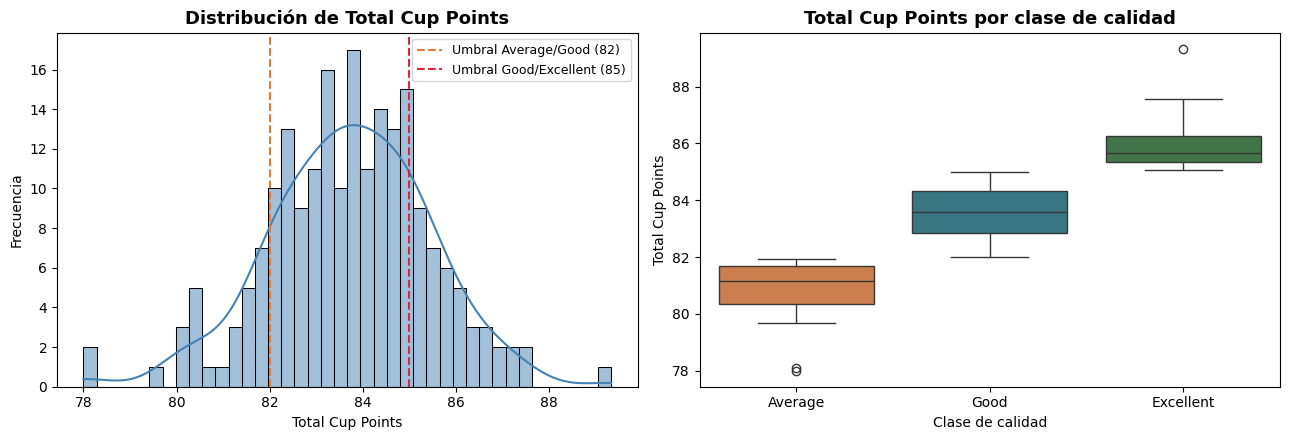

count    207.00
mean      83.71
std        1.73
min       78.00
25%       82.58
50%       83.75
75%       84.83
max       89.33
Name: Total Cup Points, dtype: float64


In [ ]:
# Crear histograma y bloxplot de Total Cup Points
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Histograma + KDE
sns.histplot(coffee['Total Cup Points'].dropna(), bins=40, kde=True,
             color='steelblue', ax=axes[0])
axes[0].axvline(82, color='#E07B39', linestyle='--',
                label='Umbral Average/Good (82)')
axes[0].axvline(85, color='#D7263D',    linestyle='--',
                label='Umbral Good/Excellent (85)')
axes[0].set_title('Distribución de Total Cup Points', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Cup Points')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

# Boxplot por clase
order_clase = ['Average', 'Good', 'Excellent']
palette = {'Average': '#E07B39', 'Good': '#2A7F8F', 'Excellent': '#3A7D44'}
sns.boxplot(data=coffee, x='Quality Class', y='Total Cup Points',
            order=order_clase, palette=palette, ax=axes[1])
axes[1].set_title('Total Cup Points por clase de calidad', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Clase de calidad')
axes[1].set_ylabel('Total Cup Points')

plt.tight_layout()
plt.show()
print(coffee['Total Cup Points'].describe().round(2))

La distribución de Total Cup Points es aproximadamente normal con leve cola a la izquierda, concentrada entre los 80 y 87 puntos. Los valores 82 y 85 dividen la distribución dejando las zonas central para la clase Good que es la más frecuente, Excellent en el lado derecha y Average en el lado izquierdo.
El boxplot confirma que las 3 clases están diferenciadas sin sobreponerse, lo que indica que clasificar los valores es posible.

Processing Method fue usado dado que el método de procesamiento afecta directamente el perfíl sensorial del café. Es una variable categórica que se incluye como predictor. Ver su distribución avisa de posible desbalance de categorías.

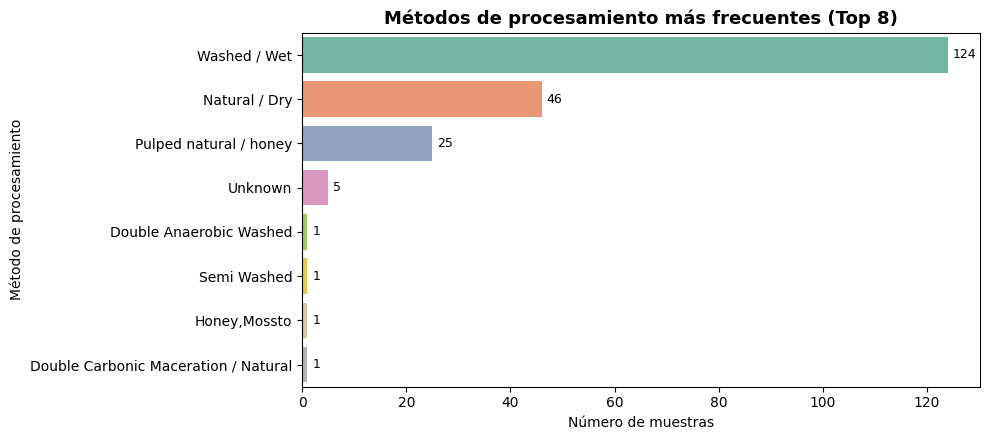

Distribución completa de Processing Method:
Processing Method
Washed / Wet                            124
Natural / Dry                            46
Pulped natural / honey                   25
NaN                                       5
Double Anaerobic Washed                   1
Semi Washed                               1
Honey,Mossto                              1
Double Carbonic Maceration / Natural      1
Wet Hulling                               1
Anaerobico 1000h                          1
SEMI-LAVADO                               1


In [ ]:
# Crear gráfico de barras con Processing Method
fig, ax = plt.subplots(figsize=(10, 4.5))

procesos = (coffee['Processing Method']
               .fillna('Unknown')
               .value_counts()
               .head(8))

bars = sns.barplot(x=procesos.values, y=procesos.index,
                   palette='Set2', ax=ax)

# Etiquetas de valor en cada barra
for i, v in enumerate(procesos.values):
    ax.text(v + 1, i, str(v), va='center', fontsize=9)

ax.set_title('Métodos de procesamiento más frecuentes (Top 8)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Número de muestras')
ax.set_ylabel('Método de procesamiento')
plt.tight_layout()
plt.show()

print("Distribución completa de Processing Method:")
print(coffee['Processing Method'].value_counts(dropna=False).to_string())

El método Washed/Wet es el más usado con más del 50% de las muestras, y el método Natural/Dry es el segundo más usado con un 25%. Este desbalanceo puede hacer que el modelo aprenda a sobre-representar el método Washed/Wet. La categoría Unknown confirma la necesidad de tratar los valores nulos.

Puntajes sensoriales por clase se usó para confirmar que las clases de calidad están efectivamente diferenciadas en los features que se usan para predecir. Si no hubiera diferencias, el modelo no podría aprender a separar las clases.

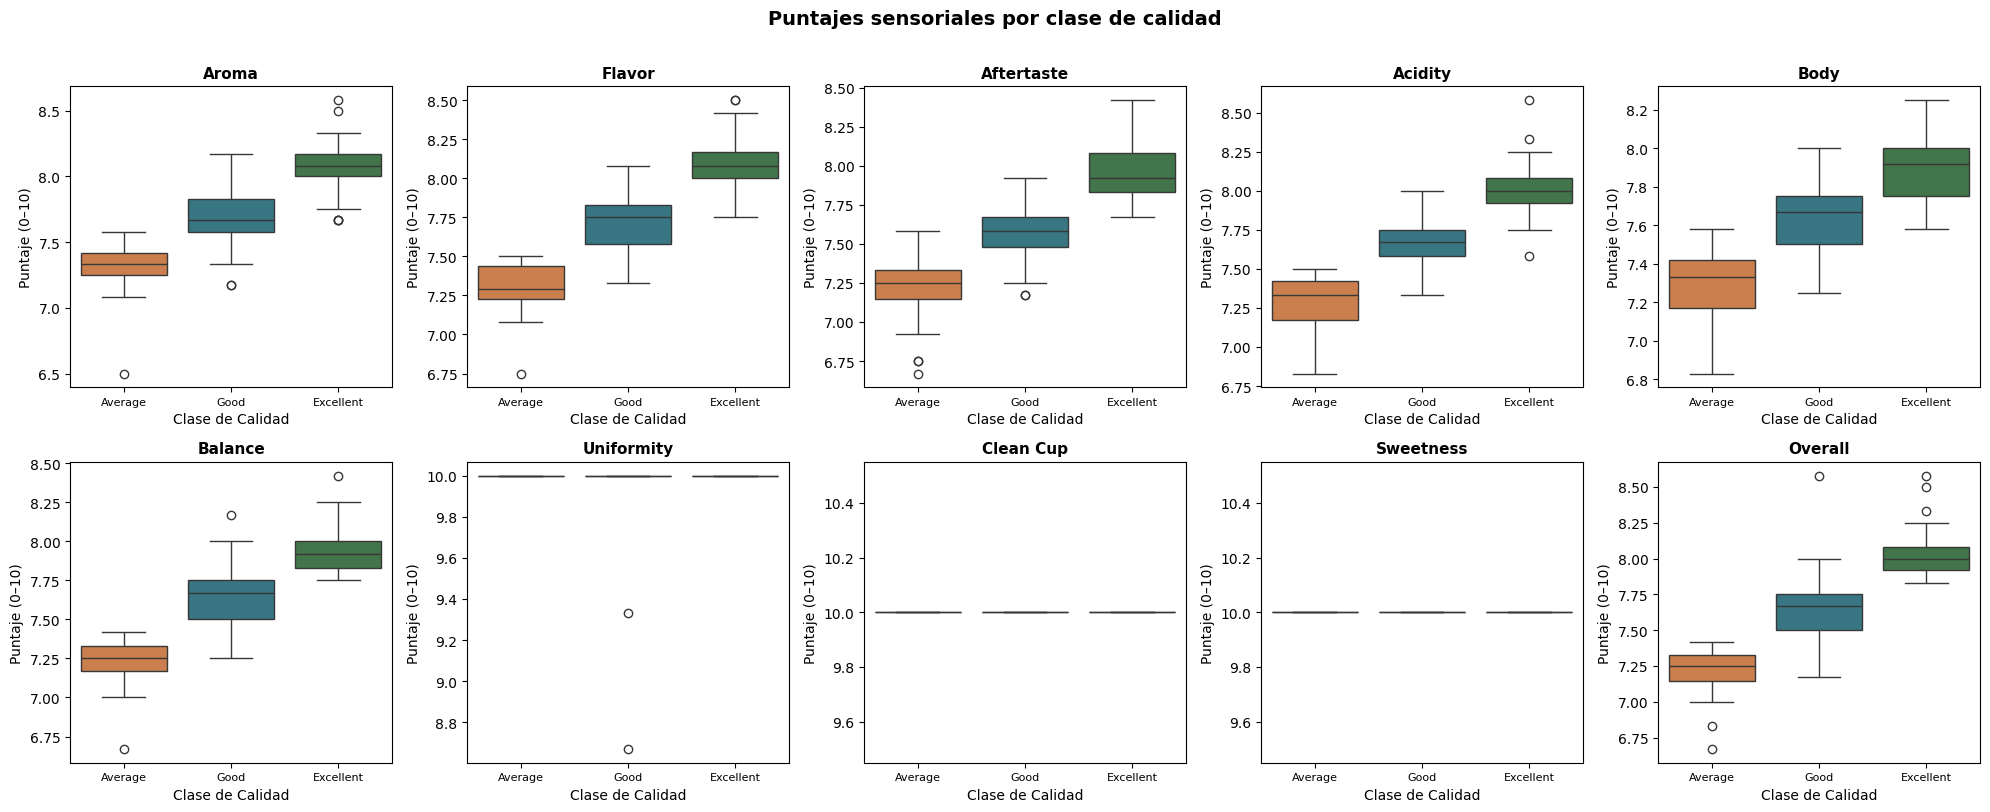

In [ ]:
# Crear bloxpot con las variables sensoriales y la objetivo
sensory_cols = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance',
                'Uniformity', 'Clean Cup', 'Sweetness', 'Overall']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(sensory_cols):
    sns.boxplot(data=coffee, x='Quality Class', y=col,
                order=order_clase, palette=palette, ax=axes[i])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Clase de Calidad')
    axes[i].set_ylabel('Puntaje (0–10)')
    axes[i].tick_params(axis='x', labelsize=8)

fig.suptitle('Puntajes sensoriales por clase de calidad',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Los puntajes sensociales muestran una tendencia creciente de Average a Excelente, es decir, los café de mayor calidad obtienen puntajes más altos en 5 de las variables. Los puntajes son buenos predictores de la clase de calidad. Uniformity, Clean Cup y Sweetness tienen valores muy cercanos a 10.

Distribución de altitud se usó para justificar con datos los úmbrales elegidos. Si el histograma muestra que lso datos se agrupan naturalmente alrededor de esos valores, la clasificación tiene respaldo.

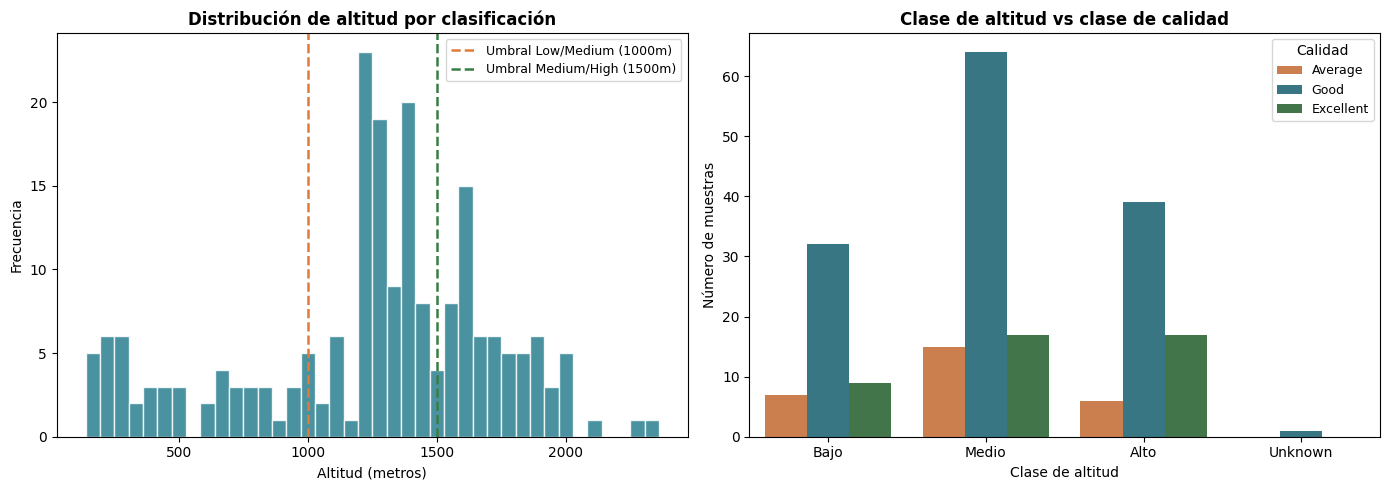

In [ ]:
# Histograma con las clasificaciones de altura
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(coffee['Altitude_m'].dropna(), bins=40,
             color='#2A7F8F', edgecolor='white', alpha=0.85)
axes[0].axvline(1000, color='#E07B39', linestyle='--', linewidth=1.8,
                label='Umbral Low/Medium (1000m)')
axes[0].axvline(1500, color='#3A7D44', linestyle='--', linewidth=1.8,
                label='Umbral Medium/High (1500m)')
axes[0].set_title('Distribución de altitud por clasificación',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Altitud (metros)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

# Conteo por clase de altitud vs clase de calidad
alt_order = ['Bajo', 'Medio', 'Alto', 'Unknown']
sns.countplot(data=coffee, x='Altitude_Class', hue='Quality Class',
              order=alt_order, hue_order=order_clase,
              palette=palette, ax=axes[1])
axes[1].set_title('Clase de altitud vs clase de calidad',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Clase de altitud')
axes[1].set_ylabel('Número de muestras')
axes[1].legend(title='Calidad', fontsize=9)

plt.tight_layout()
plt.show()

El histograma muestra que la mayoría de las muestras se concentran entre 1000m y 2000m. Los los límites de las categorías 1000m y 1500m dividen los datos en 3 grupis con suficientes muestras, lo que valida la elección. El otro gráfico de barras muestra que los café de altitud Alto tienden a concentrar más muestars Excellent, lo que confirma que la altitud es una variable relevante a predecir la calidad.

Detectar outliers muestra dónde hay granos defectusos que hay que evitar para que el modelo no aprenda reglas equivocadas. El heatmap de correlaciones sirve para observar qué features están más relacionadas entre sí, lo que ayuda a decidir si es necesario eliminar features redundantes.

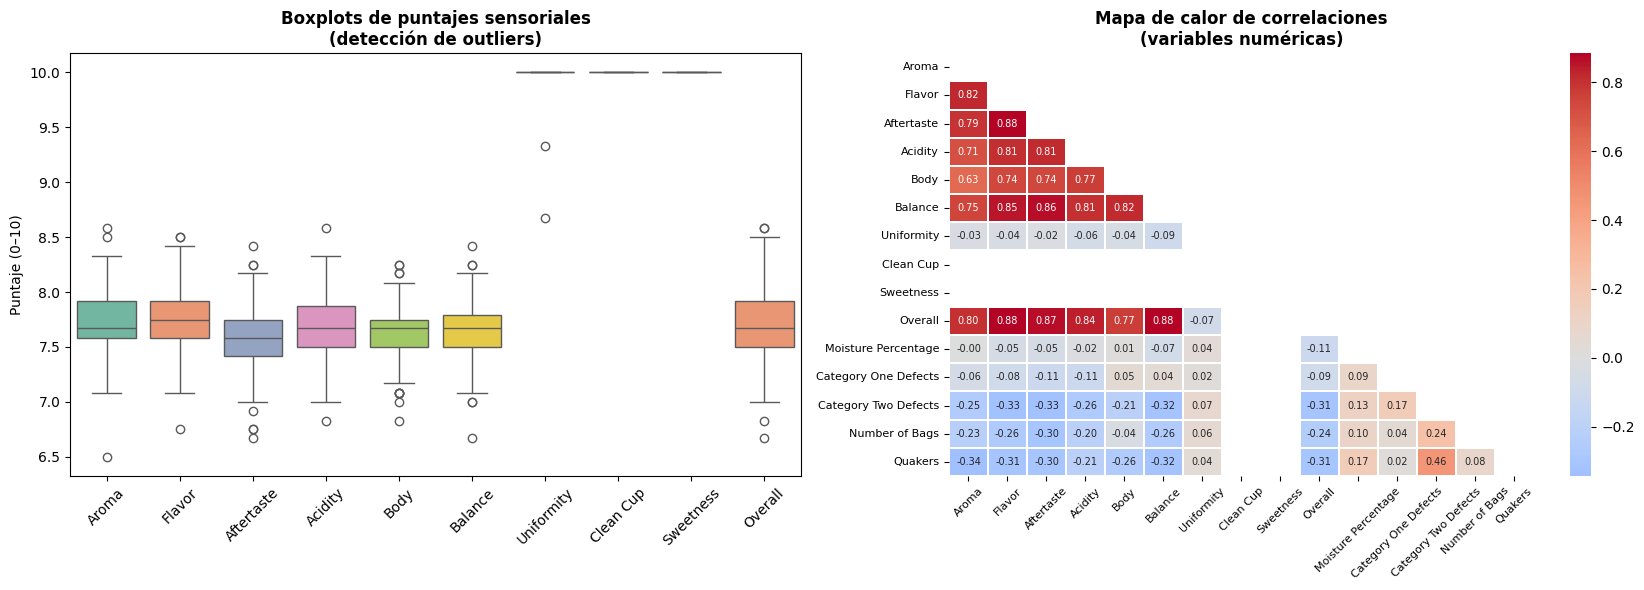

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Boxplots de outliers
sensory_cols = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance',
               'Uniformity', 'Clean Cup', 'Sweetness', 'Overall']

df_melt = coffee[sensory_cols].melt(var_name='Puntaje', value_name='Valor')
sns.boxplot(data=df_melt, x='Puntaje', y='Valor',
            palette='Set2', ax=axes[0])
axes[0].set_title('Boxplots de puntajes sensoriales\n(detección de outliers)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Puntaje (0–10)')
axes[0].tick_params(axis='x', rotation=45)

# Heatmap de correlaciones
num_cols_corr = sensory_cols + ['Moisture Percentage', 'Category One Defects',
                               'Category Two Defects', 'Number of Bags', 'Quakers']
corr_matrix = coffee[num_cols_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.3,
            annot_kws={'size': 7}, ax=axes[1])
axes[1].set_title('Mapa de calor de correlaciones\n(variables numéricas)',
                  fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

El bosxplot muestra que Uniformity, Clean Cup y Sweetness presentan outliers con valor 0, que corresponden a lotes con defectos. Aroma, Flavour y Body tienen distribuciones más compactas con outliers en la parte inferior.

El mapa de calor de correlaciones muestar que los puntos sensoriales tienen alta correlación positiva entre sí, lo que tiene sentido pues miden aspectos del mismo café. Las variables no sensoriales tienen baja o nula correlación con los puntajes sensoriales, lo que indica que la cantidad de sacos o los defectos no determinan directamente el puntaje sensorial del café.

## 1.3 Tratamiento de valores nulos

Columnas con valores nulos: 10
                   Nulos  % Nulos
ICO Number           132    63.77
Variety                6     2.90
Processing Method      5     2.42
Mill                   3     1.45
Region                 2     0.97
Farm Name              2     0.97
Lot Number             1     0.48
Altitude               1     0.48
Producer               1     0.48
Altitude_m             1     0.48


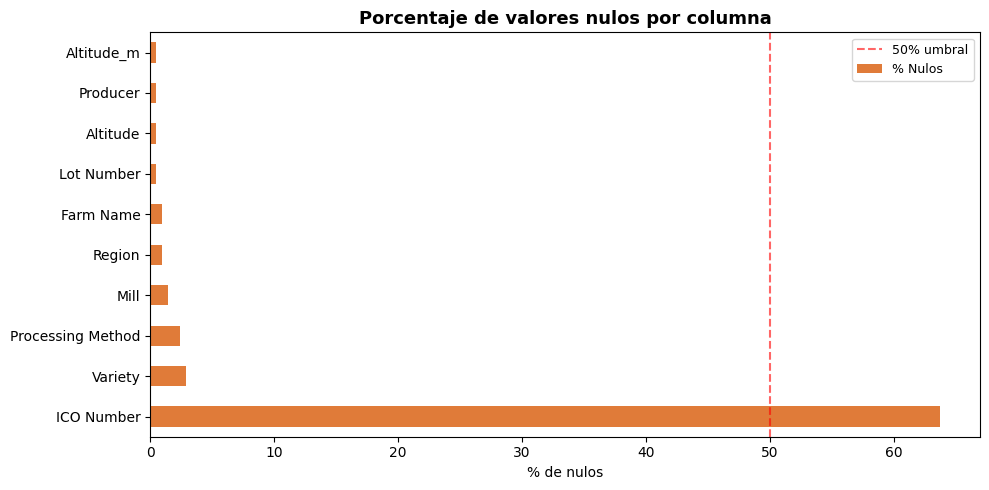

In [ ]:
# Mostrar valores nulos presentes
nulls    = coffee.isnull().sum()
null_pct = (nulls / len(coffee) * 100).round(2)
null_coffee  = pd.DataFrame({'Nulos': nulls, '% Nulos': null_pct})
null_coffee  = null_coffee[null_coffee['Nulos'] > 0].sort_values('% Nulos', ascending=False)

print(f"Columnas con valores nulos: {len(null_coffee)}")
print(null_coffee.to_string())

# Visualización de nulos
fig, ax = plt.subplots(figsize=(10, 5))
null_coffee['% Nulos'].plot(kind='barh', color='#E07B39', ax=ax)
ax.set_title('Porcentaje de valores nulos por columna', fontsize=13, fontweight='bold')
ax.set_xlabel('% de nulos')
ax.axvline(50, color='red', linestyle='--', alpha=0.6, label='50% umbral')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

El tratamiento de valores nulos se hará sobre los datos del entrenamiento dentro del pipeline de preprocesamiento para evitar data leakage, aquí sólo presentraré el análisis.

Altitude: se usará la mediana del train dado que hay una distribución asimétrica de los outliers. Aunque no séra usado tal cual, será modificado.

Variety: Hay muchas variedades, es mejor crear una categoría adicional para preservar la información.

Processing Method y Color: Moda del train dado que hay pocos nulos.

Quakers y otras numéricas: Mediana del train.

---
# 2. Feature Engineering

## 2.1 Selección de Feature

In [ ]:
# Quitar columnas que no son relevantes al modelo
COLS_DROP = [
    'Unnamed: 0', 'ID', 'Owner',
    'Farm Name', 'Lot Number', 'Mill', 'ICO Number', 'Company', 'Producer',
    'In.Country Partner', 'Certification Body',
    'Certification Address', 'Certification Contact',
    'Altitude', 'Altitude_m',   # Altitude_Class se conserva como predictora
    'Grading.Date', 'Harvest.Year', 'Expiration',
    'Bag Weight',
    'Total Cup Points' # DATA LEAKAGE: fuente directa de Quality Class
]

# Solo eliminamos las que existen
cols_to_drop = [col for col in COLS_DROP if col in coffee.columns]
coffee_clean = coffee.drop(columns=cols_to_drop).copy()

*   Unnamed: 0: corresponde a la espcie y no aporta información relevante.
*   ID y Owner: indicadores y repetida.
*   Farm Name, Lot Number, Mill, ICO Number, Company, Producer: indicadores de cada lote.
*   In Country Partner, Certifications varios: indicadores organizacionales, no relevantes.
*   Altitude, Altitude_m: se eliminan y queda Altitude_Clase
*   Grading Date, Harvest Year, Expiration: Fechas con muchos nulos.
*   Bag Weight: poca relevancia
*   Total Cup Points: Data leakage dado que es la suma de los puntajes sensociales y la fuente de Quality Class.


In [ ]:
# Definir X e Y
TARGET = 'Quality Class'
feature_cols = [col for col in coffee_clean.columns if col != TARGET]

X = coffee_clean[feature_cols].copy()
y = coffee_clean[TARGET].copy()

# Identificar tipos de feature para el pipeline
num_feats = X.select_dtypes(include = [np.number]).columns.tolist()
cat_feats = X.select_dtypes(include = ['object', 'category']).columns.tolist()

print(f'Dataset final: {X.shape[0]:,} filas x {X.shape[1]} features + 1 target')
print(f'\nFeatures numéricas ({len(num_feats)}):')
print(num_feats)
print(f'\nFeatures categóricas ({len(cat_feats)}):')
print(cat_feats)
print(f'\nDistribución del target:')
print(y.value_counts().to_string())

Dataset final: 207 filas x 26 features + 1 target

Features numéricas (16):
['Number of Bags', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness', 'Overall', 'Defects', 'Moisture Percentage', 'Category One Defects', 'Quakers', 'Category Two Defects']

Features categóricas (10):
['Country of Origin', 'Region', 'In-Country Partner', 'Harvest Year', 'Grading Date', 'Variety', 'Status', 'Processing Method', 'Color', 'Altitude_Class']

Distribución del target:
Quality Class
Good         136
Excellent     43
Average       28


A pesar de que en la visualización Uniformity, Clean Cup y Sweetness presentan extremos de 0 correspondientes a lotes con defectos graves, decidí mantenerlos porque representan información real y no errores. Esos con precisamente los atributos que distinguen cafés de baja calidad. Remover esas columnas sería quitar parte importante de la información sobre la calidad del café que es parte de este análisis y del modelo de predicción.

## 2.2 Reducción de Dimensionalidad

La técnica elegida es t-SNE con PCA como pase previo.

Dado que el objetivo es explorar visualmente si las clases de calidad forman grupos separables, t-SNE es la más adecuada. t-SNE es mejor si hay clusters no lineales, permite una visualización exploratoria

In [ ]:
# Procesamiento de X para visualización
num_pipe_vis = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipe_vis = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
     ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preproc_vis = ColumnTransformer([
    ('num', num_pipe_vis, num_feats),
    ('cat', cat_pipe_vis, cat_feats)
])

X_proc = preproc_vis.fit_transform(X)
print(f'Shape tras preprocesamiento: {X_proc.shape}')

Shape tras preprocesamiento: (207, 336)


In [ ]:
# Paso 1: PCA a 50 dimensiones
n_pca = min(50, X_proc.shape[1])
pca_pre = PCA(n_components = n_pca, random_state = RNG_SEED)
X_pca_pre = pca_pre.fit_transform(X_proc)
var_total = pca_pre.explained_variance_ratio_.sum() * 100
print(f'Varianza explicada con {n_pca} componentes PCA: {var_total:.1f}%')

Varianza explicada con 50 componentes PCA: 93.2%


Se aplicó PCA antes de t-SNE dado que con muchas features, el cómputo se vuelve lento. Reducir primero a 50 componentes con PCA acelera significativamente t-SNE sin perder información relevante.

In [ ]:
# Paso 2: t-SNE a 2D
tsne = TSNE(n_components=2,
            perplexity=30,
            n_iter=1000,
            random_state=RNG_SEED,
            learning_rate='auto',
            init='pca'
)

X_tsne = tsne.fit_transform(X_pca_pre)

Justificación de hiperparámetros de t-SNE:
*   perpléxity=30: valor por defecto recomendado. Controla el balance entre estrcutra local y global
*   n_inter=1000: suficiente para la convergencia del algoritmo con el tamaño del dataset.
*   random_state=RNG_SEED: para reproductivildiad
*   init:'pca': iniciar con PCA acelera la convergencia y produce resultados más estables.

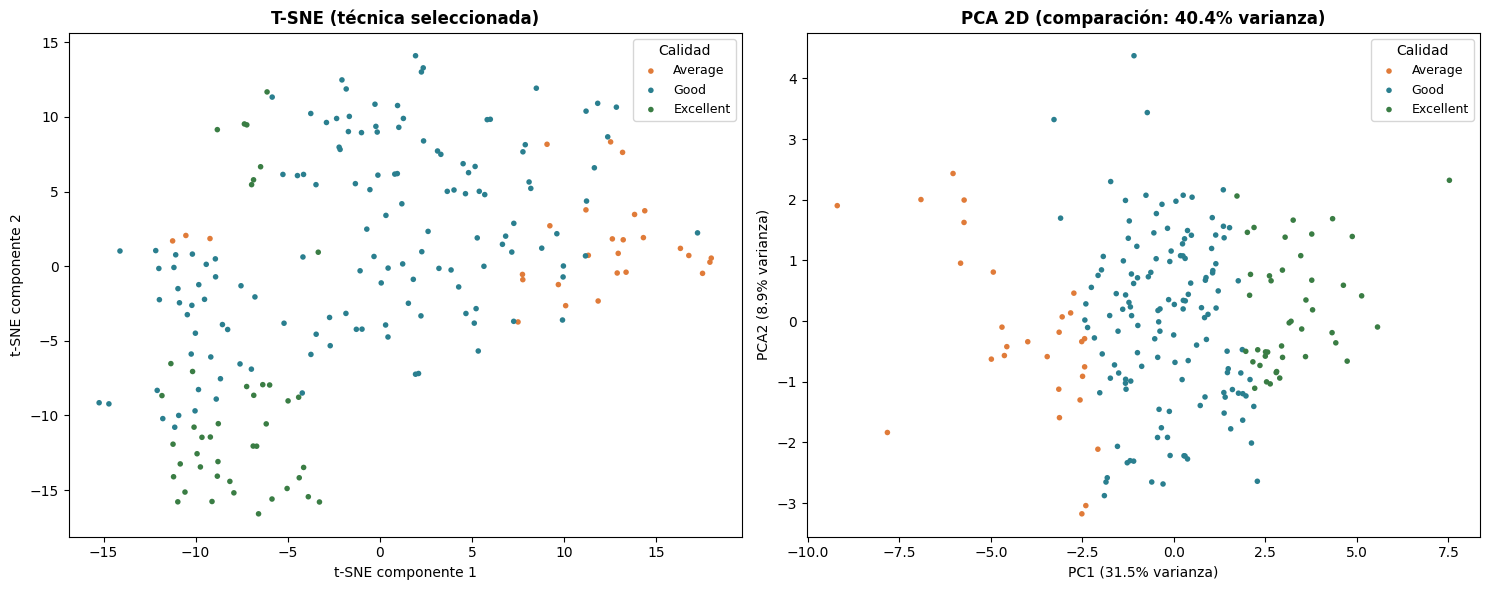


PCA 2D - varianza explicada:
 PC1: 31.48%
 PC2: 8.89%
 Total 2 componentes: 40.36%


In [ ]:
# Calcular PCA 2D para comparación
pca_2d = PCA(n_components=2, random_state=RNG_SEED)
X_pca_2d = pca_2d.fit_transform(X_proc)
var1 = pca_2d.explained_variance_ratio_[0] * 100
var2 = pca_2d.explained_variance_ratio_[1] * 100

# Visualización de ambos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, X_2d, title, xlabel, ylabel in [
    (axes[0], X_tsne, 'T-SNE (técnica seleccionada)',
     't-SNE componente 1', 't-SNE componente 2'),
    (axes[1], X_pca_2d, f'PCA 2D (comparación: {var1+var2:.1f}% varianza)',
     f'PC1 ({var1:.1f}% varianza)', f'PCA2 ({var2:.1f}% varianza)')
]:
    for cls in ['Average', 'Good', 'Excellent']:
      mask = (y == cls)
      ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                 c=palette[cls], label=cls,
                 alpha=1.0, s=16, edgecolors='none')
      ax.set_title(title, fontsize=12, fontweight='bold')
      ax.set_xlabel(xlabel)
      ax.set_ylabel(ylabel)
      ax.legend(title = 'Calidad', fontsize=9)

plt.tight_layout()
plt.show()

# Varianza explicada PCA por componente
print(f'\nPCA 2D - varianza explicada:')
print(f' PC1: {var1:.2f}%')
print(f' PC2: {var2:.2f}%')
print(f' Total 2 componentes: {var1+var2:.2f}%')

t-SNE revela que las 3 clases forman regiones relativamente diferenciadas, aunque con solapamiento entre Good y Excellent. Los puntos Average tienden a agruparse en los bordes del gráfico y lejos del núcleo.

PCA 2D captura entre un 30 y 40% de la varianza total, lo que explica porqué los clusters son menos definidos. Dos componentes principales no son suficientes para separar las clases.

El solapamiento visible en t-SNE entre Good y Excellent indica que habrá dificultad de separalos y el modelo deberá combinar múltiples features para distinguirlas, a diferencia de Average, que es la más fácil de separable.

La estructura de los clusters en t-SNE es continua, no discreta, lo que es esperado dado que los límites entre clases con umbrales arbitrarios sobre una escala continua.

---
# 3. Modelado y Evaluación

## 3.1 Train / test split

In [ ]:
# Partición estratificada 80 / 20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RNG_SEED
)

print(f'Tamaño train: {len(X_train):,} muestras ({len(X_train)/len(X)*100:.1f}%)')
print(f'Tamaño test:  {len(X_test):,} muestras ({len(X_test)/len(X)*100:.1f}%)')
print()
print('Distribución de clases en TRAIN:')
print(y_train.value_counts().to_string())
print()
print('Distribución de clases en TEST:')
print(y_test.value_counts().to_string())
print()
print('Proporción relativa (debe ser similar en ambas particiones):')
print(pd.DataFrame({
    'Train (%)': y_train.value_counts(normalize=True).round(3) * 100,
    'Test (%)':  y_test.value_counts(normalize=True).round(3) * 100
}).to_string())

Tamaño train: 165 muestras (79.7%)
Tamaño test:  42 muestras (20.3%)

Distribución de clases en TRAIN:
Quality Class
Good         109
Excellent     34
Average       22

Distribución de clases en TEST:
Quality Class
Good         27
Excellent     9
Average       6

Proporción relativa (debe ser similar en ambas particiones):
               Train (%)  Test (%)
Quality Class                     
Good                66.1      64.3
Excellent           20.6      21.4
Average             13.3      14.3


Proporción: 80% train y 20% test. Es el mínimo para un test. Un split mayor dejaría el train con muy pocos datos apra aprender. Preferí un 80/20 sobre 70/30 porque con pocas muestras es más crítico maximizar los datos de entrenamiento que ampliar el test.

Estratificación: Si (statify=y), las clases están desbalanceadas. Sin estratificación el test podría contener muestras de alguna clase, haciendo imposible su evaluación. Con un dataset tan pequeño y clases desbalanceadas, existe el riesgo de que el test no contenga ninguna muestra de Average. La estratificación garantiza que cada clase tenga la misma proporción.

Random state: RNG_SEED = 0. Garantiza que sea reproducible.

## 3.2 Model training

Comparé dos modelos: **Random Forest** y **Decision Tree**.

Random Forest es la opción natural para clasificación tabular, su estructura de ensemble reduce la varianza, maneja features irrelevante y no requiere de escalar las features. El decision Tree sirve como un complemento interpretable: su estructura de un árbol hace transparences los patrones de overfitting, lo que es útil para el análisis de la Sección 3.3.

Se reportaron 3 métricas:

- **Balanced accuracy** (primario): recall promedio por calse, lo qeu evita que la clase mayoritaria influya en la puntuación en un conjunto de datos desequilibrado.
- **F1-score macro**: pondera por igual la precisión y el recall en las tres clases, independientemente de su tamaño.
- **Confusion matrix** — muestra qué clases se confunden entre sí, no sólo la tasa de error global.

In [ ]:
# Definir el procesador
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preproc = ColumnTransformer([
    ('num', num_pipeline, num_feats),
    ('cat', cat_pipeline, cat_feats)
])

Usar Pipeline y ColumnTransformer encapsula el preprocesamiento dentro del modelo, garantizando que la mediana, moda y scaler no vean los datos del test y así evitar data leakage.

Null values are not imputed here but inside the Pipeline below. Esto se hizo de forma intencional para evitar leakage. Al encapsular la imputación en el Pipeline, scikit-learn ajusta exclusivamente sobre X-train y la aplica al test sólo en el momento de predecir:
*   Features numéricas: SimpleImputer(stratefy='median')
*   Features categóricas: SimpleImputer(strategy='most_frequest')

**Modelo 1: Random Forest**

In [ ]:
rf_pipe = Pipeline([
    ('prep', preproc),
    ('model', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RNG_SEED
  ))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

print('=' * 60)
print('MODELO 1: Random Forest (n_estimators=100)')
print('=' * 60)
print(f'Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Accuracy          : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'F1-score (macro)  : {f1_score(y_test, y_pred_rf, average='macro'):.4f}')
print()
print(classification_report(y_test, y_pred_rf,
                             target_names=['Average', 'Excellent', 'Good']))

MODELO 1: Random Forest (n_estimators=100)
Balanced Accuracy : 0.9074
Accuracy          : 0.9524
F1-score (macro)  : 0.9382

              precision    recall  f1-score   support

     Average       1.00      0.83      0.91         6
   Excellent       1.00      0.89      0.94         9
        Good       0.93      1.00      0.96        27

    accuracy                           0.95        42
   macro avg       0.98      0.91      0.94        42
weighted avg       0.96      0.95      0.95        42



El modelo obtiene balance accuracy de 0.9074 y accuracy de 0.9524. Good es la clase mayoritaria (27/42 muestras en el test) y el modelo la identifica perfectamente (recall=1.0). Los errores se concentran en Average y Excellent, ambos con 6 muestras, donde el modelo pierde 1 muestra de cada clase, probablemte clasificándola como Good. La buena precisión de Average y Excellent(1.0) indica que cuando el modelo predice las clases, nunca se equivoca. El f1-macro de 0.94 confirma un rendimiento bueno y consistente en las 3 clases.



**Modelo 2: Árbol de Decisión**

In [ ]:
dt_pipe = Pipeline([
    ('prep', clone(preproc)), # evita que los modelos compartan el mismo preporcessor
    ('model', DecisionTreeClassifier(
        max_depth=10,
        class_weight='balanced',
        random_state=RNG_SEED
  ))
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)

print('=' * 60)
print('MODELO 2: Árbol de Decisión (max_depth=10)')
print('=' * 60)
print(f'Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred_dt):.4f}')
print(f'Accuracy          : {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'F1-score (macro)  : {f1_score(y_test, y_pred_dt, average='macro'):.4f}')
print()
print(classification_report(y_test, y_pred_dt,
                             target_names=['Average', 'Excellent', 'Good']))

MODELO 2: Árbol de Decisión (max_depth=10)
Balanced Accuracy : 0.9259
Accuracy          : 0.9048
F1-score (macro)  : 0.9077

              precision    recall  f1-score   support

     Average       1.00      1.00      1.00         6
   Excellent       0.73      0.89      0.80         9
        Good       0.96      0.89      0.92        27

    accuracy                           0.90        42
   macro avg       0.90      0.93      0.91        42
weighted avg       0.92      0.90      0.91        42



El árbol de decisión obtiene mejor balanced accuracy que Random Forest (0.9359 vs 0.9074), clasificando Averafe perfectamente (f1=1.0). Sin embargo, su precisión en Excellent es baja (0.73) y tiende a sobre-predecir esta clase. En comparación, Random Forest es mas consistente entre clases, mientras que Árbol de Decisión es más extremo, perfecto en Average y menos preciso en excellent.

**Baseline: DummyClassifier**

In [ ]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RNG_SEED)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print('=' * 60)
print('BASELINE: DummyClassifier')
print('=' * 60)
print(f'Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred_dummy):.4f}')
print(f'Accuracy          : {accuracy_score(y_test, y_pred_dummy):.4f}')
print(f'F1-score (macro)  : {f1_score(y_test, y_pred_dummy, average='macro'):.4f}')
print()

BASELINE: DummyClassifier
Balanced Accuracy : 0.3333
Accuracy          : 0.6429
F1-score (macro)  : 0.2609



El DummyClissifer obtine accuracy de 0.6429 simplemente prediciendo siempre Good que representa el 64% del test. Sin embargo, su balanced accuracy es 0.3333 equivalente a adivinar al azar y su f1 macro de 0.2609 refleja que nunca predice Average ni Excellent. ésto confirma que accuracy sola es una métrica engañosa con clases desbalanceadas y valdia el use do balanced accuracy como métrica principal.

In [ ]:
# Tabla comparativa
summary = pd.DataFrame({
    'Modelo': ['DummyClassifier (baseline)', 'Árbol de Decisión', 'Random Forest'],
    'Balanced Accuracy': [
        balanced_accuracy_score(y_test, y_pred_dummy),
        balanced_accuracy_score(y_test, y_pred_dt),
        balanced_accuracy_score(y_test, y_pred_rf)
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'F1-score (macro)': [
        f1_score(y_test, y_pred_dummy, average='macro'),
        f1_score(y_test, y_pred_dt, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ]

}).set_index('Modelo').round(4)

print("TABLA COMPARATIVA:")
print(summary.to_string())

TABLA COMPARATIVA:
                            Balanced Accuracy  Accuracy  F1-score (macro)
Modelo                                                                   
DummyClassifier (baseline)             0.3333    0.6429            0.2609
Árbol de Decisión                      0.9259    0.9048            0.9077
Random Forest                          0.9074    0.9524            0.9382


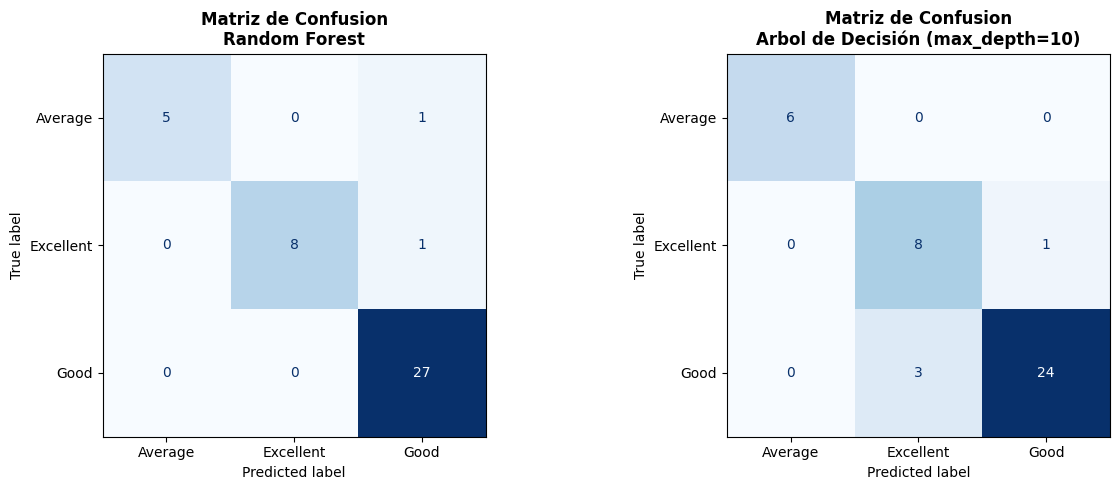

In [ ]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
class_labels = ['Average', 'Excellent', 'Good']

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_dt],
    ['Random Forest', 'Arbol de Decisión (max_depth=10)']):
  ConfusionMatrixDisplay.from_predictions(
      y_test, y_pred,
      display_labels=class_labels,
      colorbar=False,
      cmap='Blues',
      ax=ax
  )
  ax.set_title(f'Matriz de Confusion\n{title}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


Análisis comparativo de modelos:
*   Random Forest: superó al Árbol de Decisión en todas las métricas, especialmente en balanced accuracy. El ensamble de 100 árboles reduce la varianza del modelo y mejora la generalización lo que valioso con sólo 207 muestras.
*   Árbol de Decisión: superó ampliamente al baseline, pero comete más errores en la clase Average y Excellent que son las minoritarias. Un único error tiene un gran impacto.
*   Ambos modelos superan al Dummy de forma consistente, lo que confirma que los patrones aprendidos son reales.
*   El balance accuracy es más informativa que la accuracy. El Dummy puedo obtner más de 60% de accuracy prediciendo siempre Good, pero su balance accuracy es sólo 0.33.
*   Limitación: dado que la muestra en test son de 42 y con 6 en la clase minoritaria, los resutlado deben interpretarse con cautela.





## 3.3  Análisis de Overfitting

Utilicé Decision Tree para demostrar el sobreajuste, ya que `max_depth` ofrece un único control interpretable sobre la complejidad del modelo, lo que facilita la observación de la divergencia entre los conjuntos de entrenamiento y prueba. Random Forest no es una buena opción para este análisis, ya que el promedio del conjunto de 100 árboles oculta, por su propio diseño, el overfitting de cada árbol individual.

Variar `max_depth` de 1 a 30 responde a una pregunta clara: ¿a qué profundidad deja el árbol de generalizar y empieza a memorizar? Se utiliza la precisión equilibrada en ambas particiones para que la métrica sea coherente con el resto de la evaluación.

In [ ]:
depths = list(range(1, 31))
train_scores = []
test_scores = []

for depth in depths:
  pipe_ov = Pipeline([
    ('prep', clone(preproc)), # evita que los modelos compartan el mismo preporcessor
    ('model', DecisionTreeClassifier(
        max_depth=depth,
        class_weight='balanced',
        random_state=RNG_SEED
  ))
])
  pipe_ov.fit(X_train, y_train)
  train_scores.append(balanced_accuracy_score(y_train, pipe_ov.predict(X_train)))
  test_scores.append(balanced_accuracy_score(y_test, pipe_ov.predict(X_test)))


# Encontrar la profundidad óptima en test
best_idx   = int(np.argmax(test_scores))
best_depth = depths[best_idx]
best_score = test_scores[best_idx]

print(f'Profundidad óptima en test: max_depth = {best_depth}')
print(f'Balanced accuracy en test : {best_score:.4f}')
print(f'Balanced accuracy en train: {train_scores[best_idx]:.4f}')

Profundidad óptima en test: max_depth = 4
Balanced accuracy en test : 0.9259
Balanced accuracy en train: 0.9908


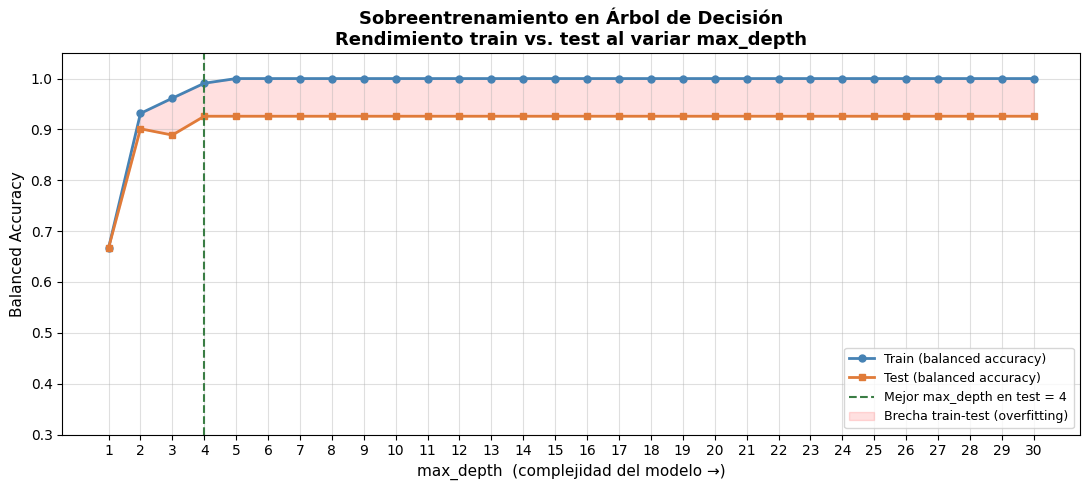

In [ ]:
# Gráfico de overfitting
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(depths, train_scores, 'o-', color='steelblue',
        linewidth=2, markersize=5, label='Train (balanced accuracy)')
ax.plot(depths, test_scores, 's-', color='#E07B39',
        linewidth=2, markersize=5, label='Test (balanced accuracy)')
ax.axvline(best_depth, color='#3A7D44', linestyle='--', linewidth=1.5,
           label=f'Mejor max_depth en test = {best_depth}')
ax.fill_between(depths, train_scores, test_scores,
                alpha=0.12, color='red', label='Brecha train-test (overfitting)')

ax.set_title('Sobreentrenamiento en Árbol de Decisión\n'
             'Rendimiento train vs. test al variar max_depth',
             fontsize=13, fontweight='bold')
ax.set_xlabel('max_depth  (complejidad del modelo →)', fontsize=11)
ax.set_ylabel('Balanced Accuracy', fontsize=11)
ax.set_xticks(depths)
ax.set_ylim(0.3, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# Tabla resumen
result_ov = pd.DataFrame({
    'max_depth': depths,
    'Train Balanced Acc': np.round(train_scores, 4),
    'Test Balanced Acc':  np.round(test_scores, 4),
    'Brecha (train-test)': np.round(np.array(train_scores) - np.array(test_scores), 4)
})
print('\nResumen por profundidad (primeras y últimas filas):')
print(pd.concat([result_ov.head(8), result_ov.tail(5)]).to_string(index=False))


Resumen por profundidad (primeras y últimas filas):
 max_depth  Train Balanced Acc  Test Balanced Acc  Brecha (train-test)
         1              0.6667             0.6667               0.0000
         2              0.9315             0.9012               0.0302
         3              0.9614             0.8889               0.0725
         4              0.9908             0.9259               0.0649
         5              1.0000             0.9259               0.0741
         6              1.0000             0.9259               0.0741
         7              1.0000             0.9259               0.0741
         8              1.0000             0.9259               0.0741
        26              1.0000             0.9259               0.0741
        27              1.0000             0.9259               0.0741
        28              1.0000             0.9259               0.0741
        29              1.0000             0.9259               0.0741
        30              

El gráfico muestra que la profundid óptima es max_depth=4, con balanced accuracy en test de 0.9259 y en train de 0.9908. A partir de depth 5 el train alcanza 1.0, el árbol memoriza completamente los datos de entrenamiento, mientras que el test se estabiliza en 0.9259 con una brecha constante de 0.07141. Este comportamiento de profundidad es común en dataset pequeños: el overfitting ocurre en un sólo paso de profundidad y el test no sigue bajando proque el árbol ya agotó su capacidad de memorización con 207 muestras.

